In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("Walmart DataSet.csv")
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


### Data Cleaning & Visualization

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
data.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
type(data["Date"])

pandas.core.series.Series

In [8]:
# convert the date column to datetime format with %d-%m-%y
data['Date']=pd.to_datetime(data['Date'],format='%d-%m-%Y')

In [9]:
data.duplicated().sum()

0

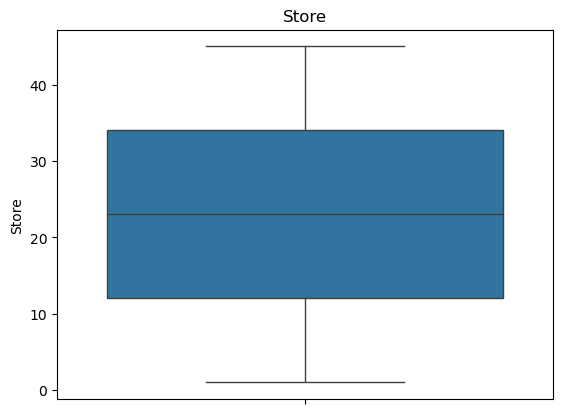

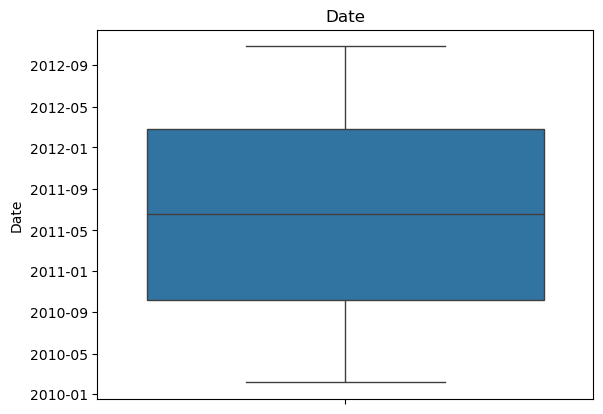

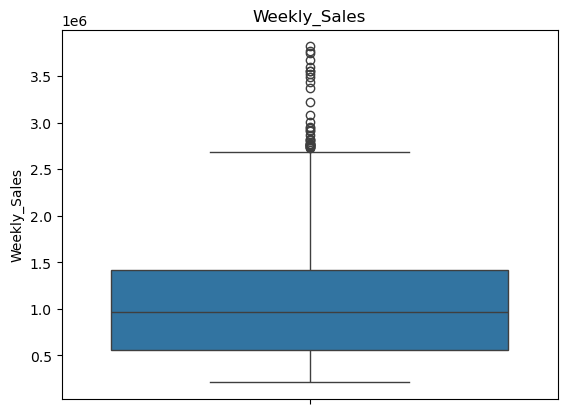

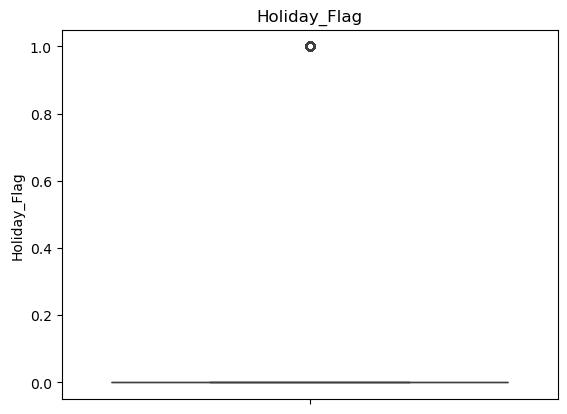

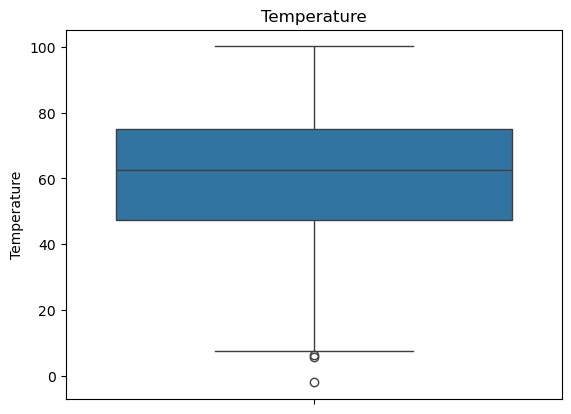

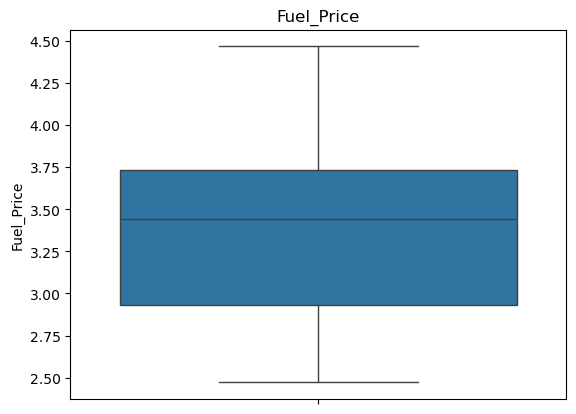

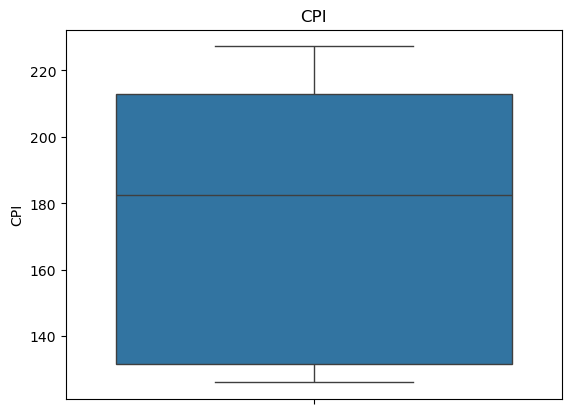

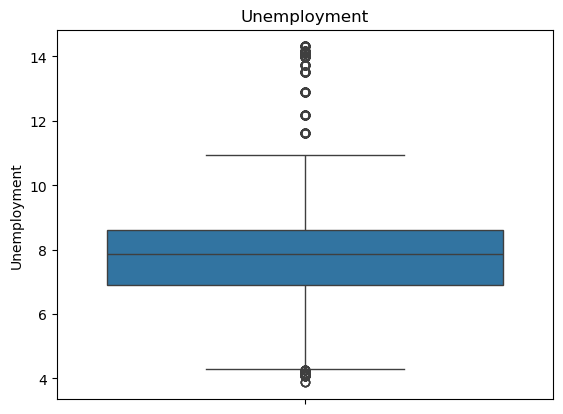

In [10]:
#outlier analysis
for x in data.columns:
  if data[x].dtype!='object':
    sns.boxplot(data[x])
    plt.title(x)
    plt.show()

In [11]:
#handling outliers
outliers=['Weekly_Sales','Unemployment']

In [12]:
for x in outliers:
  q1=data[x].quantile(0.25)
  q3=data[x].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  data=data[(data[x]>=lower) & (data[x]<=upper)]

In [13]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667


### Statistical Data Analysis

In [14]:
# to find the correlation between weekly_sales and Unemployment column
data[['Weekly_Sales','Unemployment']].corr()

#since the correlation between weekly sales and unemployment column is -0.07 which is close to 0, that implies it is hardly possible that sales are affected by unemployment

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.073227
Unemployment,-0.073227,1.000000


In [15]:
# Group data by store and calculate the correlation for each store
store_correlations = data.groupby('Store')[['Weekly_Sales', 'Unemployment']].corr()
print(store_correlations)

                    Weekly_Sales  Unemployment
Store                                         
1     Weekly_Sales      1.000000     -0.097955
      Unemployment     -0.097955      1.000000
2     Weekly_Sales      1.000000      0.054288
      Unemployment      0.054288      1.000000
3     Weekly_Sales      1.000000     -0.230413
...                          ...           ...
43    Unemployment     -0.201954      1.000000
44    Weekly_Sales      1.000000     -0.780076
      Unemployment     -0.780076      1.000000
45    Weekly_Sales      1.000000     -0.004041
      Unemployment     -0.004041      1.000000

[90 rows x 2 columns]


In [16]:
# Find stores with the most negative correlation (most affected by unemployment)
stores_suffering_most = store_correlations.sort_values(by='Unemployment')
print(stores_suffering_most)


                    Weekly_Sales  Unemployment
Store                                         
44    Weekly_Sales      1.000000     -0.780076
4     Weekly_Sales      1.000000     -0.633422
13    Weekly_Sales      1.000000     -0.400254
39    Weekly_Sales      1.000000     -0.384681
42    Weekly_Sales      1.000000     -0.356355
...                          ...           ...
28    Unemployment     -0.066340      1.000000
29    Unemployment      0.084682      1.000000
30    Unemployment      0.201862      1.000000
6     Unemployment      0.016833      1.000000
45    Unemployment     -0.004041      1.000000

[90 rows x 2 columns]


In [22]:
data.set_index(data['Date'],inplace=True)
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,,
2010-02-05,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
2012-09-28,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
2012-10-05,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
2012-10-12,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667


In [23]:
data.drop('Date',axis=1,inplace=True)
data

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...
2012-09-28,45,713173.95,0,64.88,3.997,192.013558,8.684
2012-10-05,45,733455.07,0,64.89,3.985,192.170412,8.667
2012-10-12,45,734464.36,0,54.47,4.000,192.327265,8.667


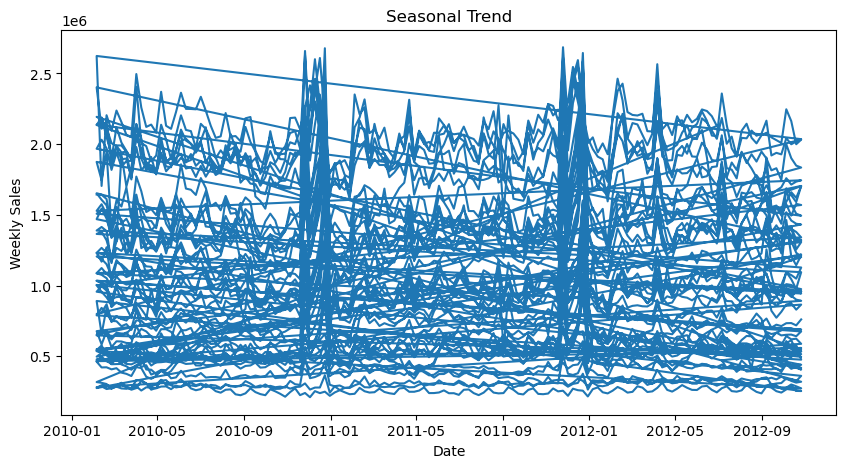

In [24]:
#If the weekly sales show a seasonal trend, when and what could be the reason?
plt.figure(figsize=(10,5))
plt.plot(data.index,data['Weekly_Sales'])
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Seasonal Trend')
plt.show()

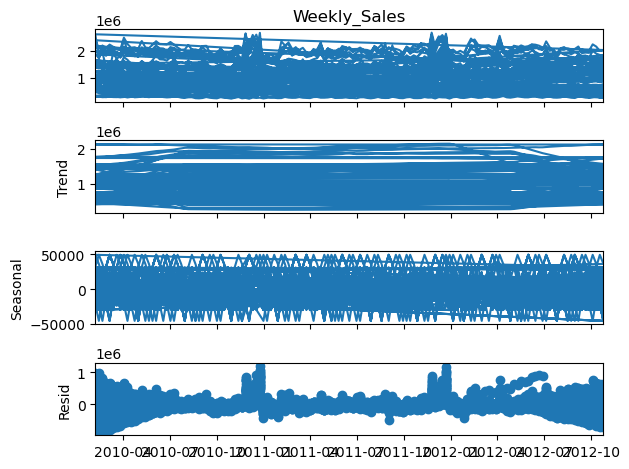

In [25]:
# to check seasonal decompose, period=52 as 52 weeks in 1 year, if it was monthly data then period would have been 12
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition= seasonal_decompose(data['Weekly_Sales'],period=52,model='additive')
decomposition.plot()
plt.show()

In [26]:
# Kruskal-Wallis Test is used to check for seasonality without graph
from scipy.stats import kruskal

def seasonality_test(series):
        seasonal = False
        idx = np.arange(len(series.index)) % 52
        H_statistic, p_value = kruskal(series, idx)
        if p_value <= 0.05:
            seasonal = True
        return seasonal

seasonality_test(data['Weekly_Sales'])

True

In [27]:
#creating a new dataframe with only information of weekly sales of store number 22
df22=pd.DataFrame(data[data['Store']==22].groupby('Date')['Weekly_Sales'].sum())
df22

,Weekly_Sales
Date,
2010-02-05,1033017.37
2010-02-12,1022571.25
2010-02-19,988467.61
2010-02-26,899761.48
2010-03-05,1009201.24
...,...
2012-09-28,976479.51
2012-10-05,1009887.36
2012-10-12,1004039.84


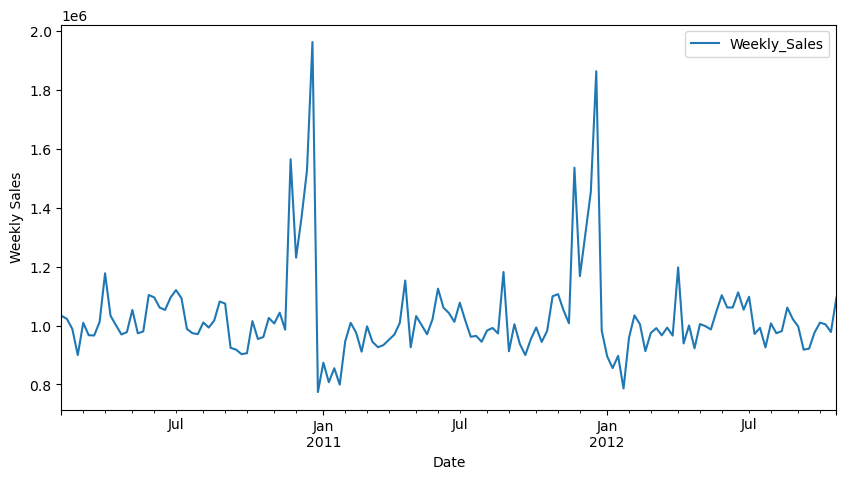

In [28]:
# plot of weekly sales of store number 22
df22.plot(figsize=(10,5))
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

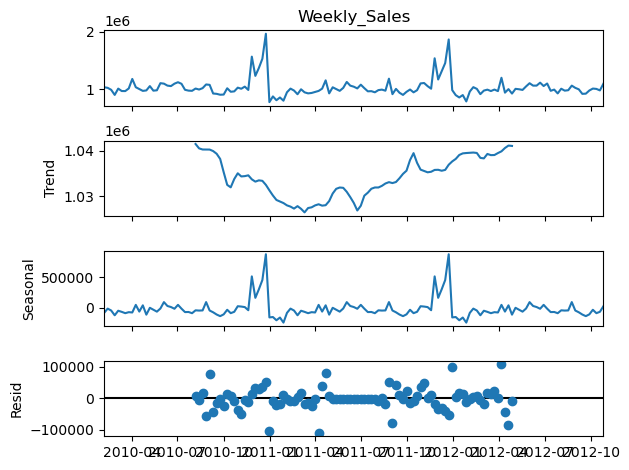

In [29]:
# seasonal decompose of store 22
decomposition1= seasonal_decompose(df22['Weekly_Sales'],period=52,model='additive')
decomposition1.plot()
plt.show()

# seasonality is around the beginning of each year, it might be because of new year people tend to shop more as compared to rest of the year therefore sales are increased

In [30]:
#Does temperature affect the weekly sales in any manner?
data[['Weekly_Sales','Temperature']].corr()

#since correlation between temperatrue and weekly sales is -0.04 which is close to 0, hance we can say there's hardly any correlation i.e. temperature does not affect sales

,Weekly_Sales,Temperature
Weekly_Sales,1.000000,-0.040918
Temperature,-0.040918,1.000000


In [31]:
#How is the Consumer Price index affecting the weekly sales of various stores?
data[['Weekly_Sales','CPI']].corr()

,Weekly_Sales,CPI
Weekly_Sales,1.000000,-0.082957
CPI,-0.082957,1.000000


In [32]:
#store wise correlation of weekly sales and CPI
affected_data= data.groupby('Store')[['Weekly_Sales','CPI']].corr()
print(affected_data)

most_affected= affected_data.sort_values(by='CPI')
print(most_affected)

                    Weekly_Sales       CPI
Store                                     
1     Weekly_Sales      1.000000  0.225408
      CPI               0.225408  1.000000
2     Weekly_Sales      1.000000 -0.063786
      CPI              -0.063786  1.000000
3     Weekly_Sales      1.000000  0.317250
...                          ...       ...
43    CPI              -0.285686  1.000000
44    Weekly_Sales      1.000000  0.740150
      CPI               0.740150  1.000000
45    Weekly_Sales      1.000000 -0.023548
      CPI              -0.023548  1.000000

[90 rows x 2 columns]
                    Weekly_Sales       CPI
Store                                     
36    Weekly_Sales      1.000000 -0.915095
14    Weekly_Sales      1.000000 -0.498495
35    Weekly_Sales      1.000000 -0.424107
30    Weekly_Sales      1.000000 -0.298188
43    Weekly_Sales      1.000000 -0.285686
...                          ...       ...
29    CPI              -0.072530  1.000000
7     CPI               0.28904

In [33]:
#Top performing stores according to the historical data.
top=data.groupby('Store')['Weekly_Sales'].sum()#.sort_values(ascending=False)
top.sort_values(ascending=False)

#The worst performing store, and how significant is the difference between the highest and lowest performing stores.
low=data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=True)

highest=top.max()
lowest=low.min()
difference=highest-lowest
print(f'the significant difference between highest and lowest sale is {difference}')

the significant difference between highest and lowest sale is 272676355.92
